# Installation des librairies importantes et importation des données

In [1]:
# Install the ultralytics package using pip
!pip install -q ultralytics

from ultralytics import YOLO
from matplotlib import pyplot as plt
from PIL import Image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [29]:
HOME = '/content/'
!mkdir {HOME}/Detection
%cd {HOME}/Detection

!pip install roboflow --quiet

from roboflow import Roboflow
rf = Roboflow(api_key="lOVTQ88BgSlHqrup7AYi")
project = rf.workspace("dissertation-bqltf").project("apple-detection-tg6vd")
dataset = project.version(1).download("yolov8")

/content/Detection
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 83.5 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Apple-Detection-1 in yolov8:: 100%|██████████| 2014/2014 [00:01<00:00, 1152.74it/s]


# Composition des images dans la base d'entrainement, validation et test

In [31]:
import os
path_dataset = '/content/Detection/Apple-Detection-1'
for ix in os.listdir(path_dataset):
  if os.path.isdir(os.path.join(path_dataset,ix)):
    s=0
    for ids in os.listdir(os.path.join(path_dataset,ix,'images')):
      if os.path.isfile(os.path.join(path_dataset,ix,'images',ids)):
        s+=1
    print(ix,s)

valid 100
train 570
test 331


# Apprentissage

Paramètre ci-dessous à changer:
- model=

Vous avez le choix de: yolo11n, yolo11m

- batch= nombre de batch
- epochs= nombre depoch
- lr0= taux dapprentissage

In [ ]:
!yolo task=detect mode=train model=yolo11n.pt data='/content/Detection/Apple-Detection-1/data.yaml' imgsz=720 plots=True patience=5 batch=2 epochs=10 lr0=0.01  --no-augment --no-mosaic --no-mixup

Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Detection/Apple-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=720, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0, p

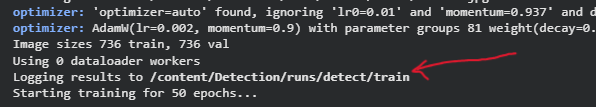

Le flèche rouge vous indique le chemin où est sauvegarder les sorties de votre entrainement : courbes d'apprentissage, échantillon d'objets prédites, meilleur modèle sauvegardé

# Evaluation

Ici, on évalue le meilleur modèle obtenu au-dessus sur les images test.

Paramètre ci-dessous à changer:
- model= chemin vers le /weights/best.pt
- conf= garder les boites ayant une conf au-dessus du seuil

In [25]:
!yolo val model='runs/detect/train2/weights/best.pt' data='/content/Detection/Apple-Detection-1/data.yaml' split=test imgsz=640 batch=16 conf=0.25 iou=0.6